# 01 · Explore the measurements

One figure per reactor, a **2 × 3 grid** of panels:

| | | |
|---|---|---|
| biomass `X` (+ spline fit) | glucose `S` | dissolved oxygen `DOTm` |
| specific growth rate `µ = (dX/dt)/X` | acetate `A` | glucose boluses (µL) |

This mirrors `mode/scripts/plot_measurements.py`, with the growth-rate panel added.

**The growth-rate panel and the spline on the biomass panel.** A smoothing spline is fitted
to `log(X)` and `µ = d/dt log(X)` is read straight off it. The fitted curve `exp(spline)` is
drawn over the biomass points (grey line). The spline is
`scipy.interpolate.make_smoothing_spline` — a penalised **natural cubic smoothing spline**
(cubic B-spline basis, penalty on the integrated squared second derivative). See
`reward_shaping/growth.py`.

**Regularization.** Set `SPLINE_LAM` in the cell below. `None` lets the spline pick its own
smoothing by generalised cross-validation; a positive number fixes the penalty weight —
**larger = stiffer**. Re-run the plotting cells after changing it.

**The two challenge stages.** The six **training** reactors are drawn first, in the expert's
known order. The five **validation** reactors follow, in plain numeric id order — their
expert ranking is hidden on the challenge server, so no rank or class is shown for them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reward_shaping import (
    load_training, load_validation, build_reactor, MissingChannel, growth_rate,
    TRAINING_EXPERT_RANKING, VALIDATION_IDS,
)

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
})

# the reference script's palette
BLUE, RED, INK, MUTED, GREEN = "#2a78d6", "#c0392b", "#333333", "#8a8a8a", "#00926c"

training = load_training()
validation = load_validation()
print("training  :", TRAINING_EXPERT_RANKING, "(expert order, best first)")
print("validation:", VALIDATION_IDS, "(numeric order -- expert ranking is hidden)")

training  : [20294, 20293, 17201, 16738, 16748, 16736] (expert order, best first)
validation: [16737, 16742, 17191, 17193, 20285] (numeric order -- expert ranking is hidden)


In [2]:
# --- spline regularization for the biomass fit / growth rate -------------------
# None  -> the spline chooses its own smoothing by generalised cross-validation
# float -> fixed penalty weight (lambda); LARGER = stiffer / smoother mu.
#          ~0.1 barely nudges it, ~1 removes most noise wiggle, ~100 is nearly a
#          straight log-linear fit. Re-run the plotting cells after changing this.
SPLINE_LAM = None
# ----------------------------------------------------------------------------- -

In [3]:
def plot_experiment(experiment, reactor, axes, spline_lam=None):
    """Draw one reactor onto a prepared 2x3 array of axes.

        [0,0] biomass X (+ spline fit)   [0,1] glucose S      [0,2] DOTm
        [1,0] specific growth rate mu    [1,1] acetate A      [1,2] glucose boluses

    ``spline_lam`` is passed to ``growth_rate(s=...)``: None lets cross-validation pick
    the smoothing, a positive float fixes it (larger = stiffer).
    """
    obs = reactor["observations"]

    tX, X = obs["X"]
    # spline fit on log(X); X_dense = exp(spline), mu_dense = d/dt log(X)
    t_dense, mu_dense, X_dense, _ = growth_rate(tX, X, s=spline_lam)

    # --- [0,0] biomass, with the smoothing-spline fit the growth rate is taken from ---
    lam_txt = "GCV-chosen smoothing" if spline_lam is None else ("lambda = %g" % spline_lam)
    axes[0, 0].plot(tX, X, "o", color=BLUE, ms=4, label="measured")
    axes[0, 0].plot(t_dense, X_dense, "-", color=INK, lw=1.3, alpha=0.8,
                    label="natural cubic smoothing spline\n(fit to log X, %s)" % lam_txt)
    axes[0, 0].legend(fontsize=7, frameon=False)
    axes[0, 0].set_title("biomass X, g/L")

    # --- [0,1] glucose ---
    t, v = obs["S"]
    axes[0, 1].plot(t, v, "o", color=GREEN, ms=4, label="at-line")
    if experiment.has("Glucose", 9):  # 9 == OFFLINE_DEVICE, the Cedex assay
        off_t, off_v = experiment.series("Glucose", device=9)
        off_t = off_t - reactor["biomass_start"]           # onto the reactor clock
        keep = (off_t >= 0) & (off_t <= reactor["horizon"])
        axes[0, 1].plot(off_t[keep], off_v[keep], "o", mfc="none", color=INK, ms=5,
                        label="offline assay")
        axes[0, 1].legend(fontsize=7, frameon=False)
    axes[0, 1].set_title("glucose S, g/L")

    # --- [0,2] DOTm ---
    t, v = obs["DOTm"]
    axes[0, 2].plot(t, v, "-", color=RED, lw=1.2)
    axes[0, 2].set_ylim(bottom=0.0)
    axes[0, 2].set_title("DOTm, fraction of air saturation")

    # --- [1,0] specific growth rate ---
    axes[1, 0].plot(t_dense, mu_dense, "-", color=BLUE, lw=1.5)
    axes[1, 0].axhline(0.0, color=INK, lw=0.7, alpha=0.5)
    mu_max = float(np.nanmax(mu_dense))
    t_at_max = float(t_dense[np.nanargmax(mu_dense)])
    axes[1, 0].plot([t_at_max], [mu_max], "o", color=RED, ms=5)
    axes[1, 0].annotate("mu_max = %.2f /h  at t = %.1f h" % (mu_max, t_at_max),
                        xy=(0.97, 0.94), xycoords="axes fraction",
                        ha="right", va="top", fontsize=8, color=RED)
    axes[1, 0].set_title("specific growth rate mu = (dX/dt)/X, 1/h")

    # --- [1,1] acetate ---
    t, v = obs["A"]
    axes[1, 1].plot(t, v, "o", color=MUTED, ms=4)
    axes[1, 1].set_title("acetate A, g/L")

    # --- [1,2] glucose boluses ---
    pulse_t, pulse_v, _ = reactor["pulses"]
    axes[1, 2].bar(pulse_t, 1e6 * pulse_v, width=0.06, color=INK)
    axes[1, 2].set_title("%s glucose bolus, uL" % (reactor["pulse_source"],))

    for ax in axes.flat:
        ax.set_xlabel("time, h")
        ax.set_xlim(0.0, reactor["horizon"])


def draw(experiment, reactor, title, filename, fig_dir):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    plot_experiment(experiment, reactor, axes, spline_lam=SPLINE_LAM)
    fig.suptitle(title, y=1.02, fontsize=11)
    fig.tight_layout()
    fig.savefig(fig_dir / filename, dpi=130, bbox_inches="tight")
    plt.show()

## Training reactors — expert order known

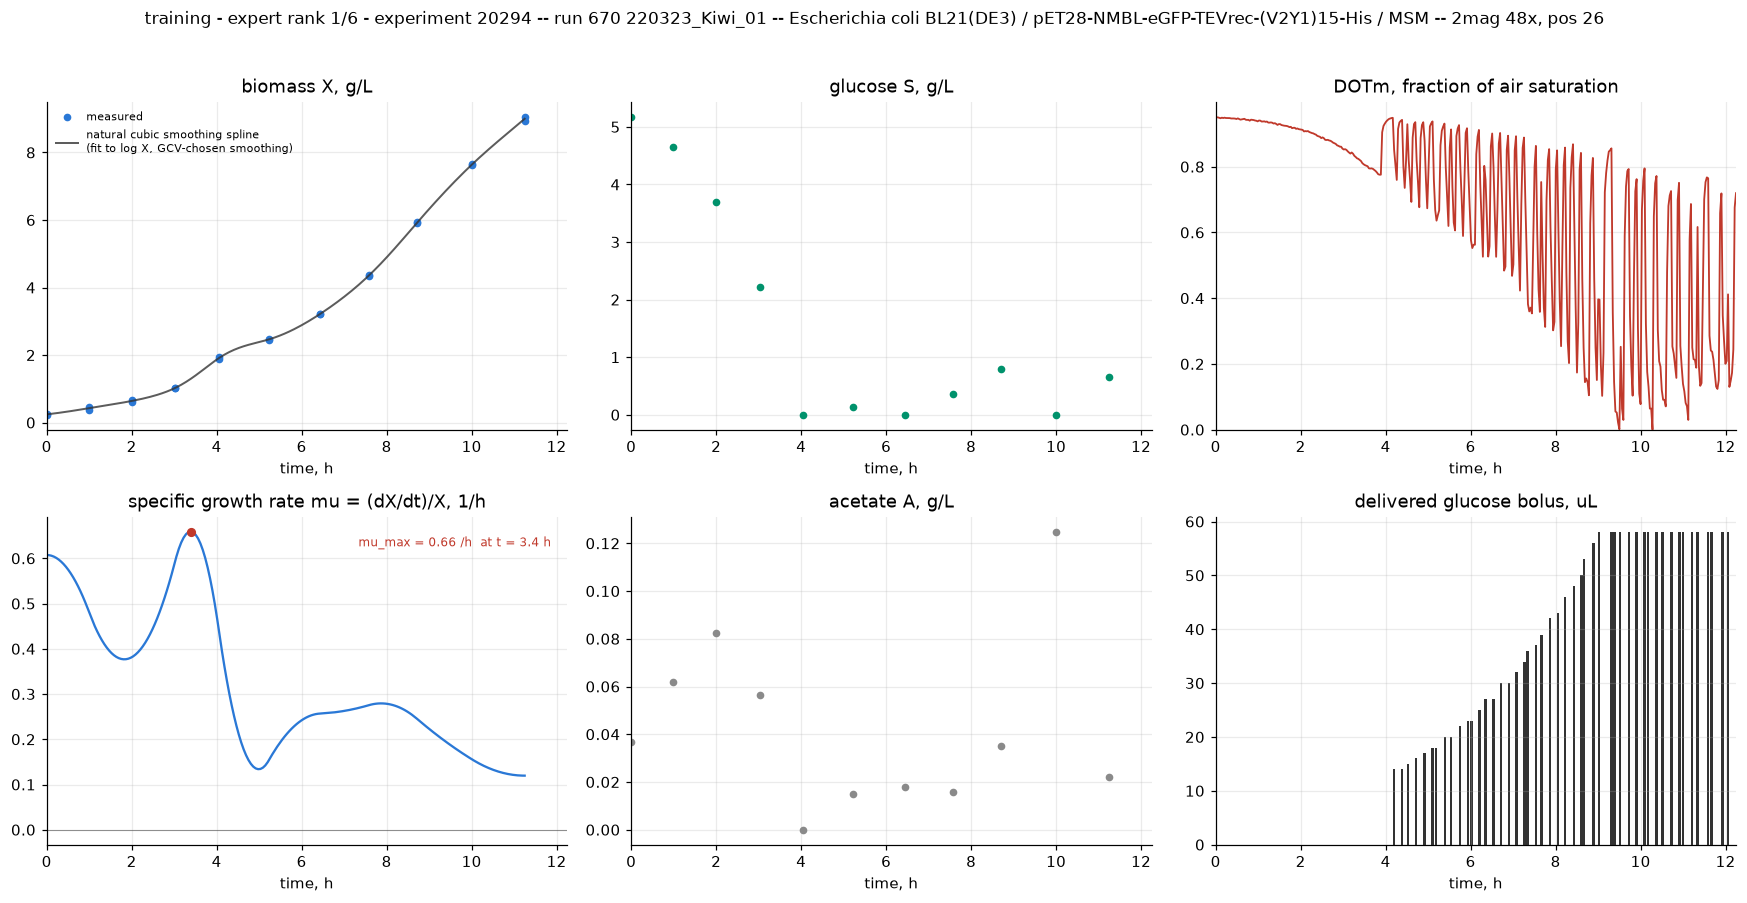

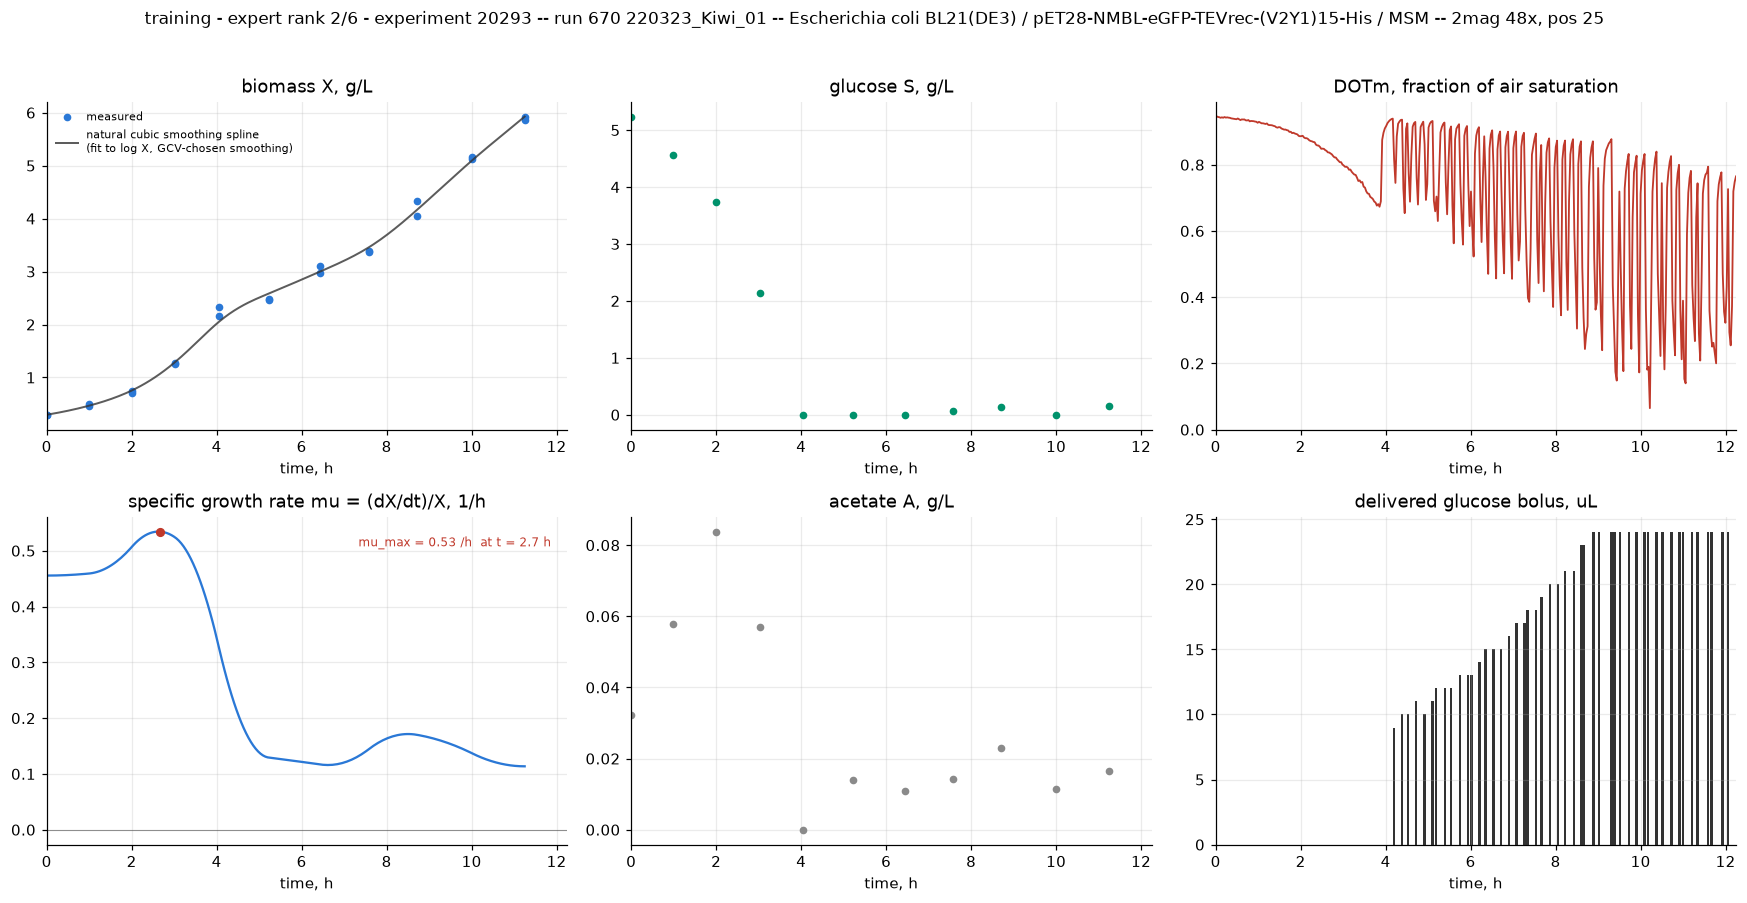

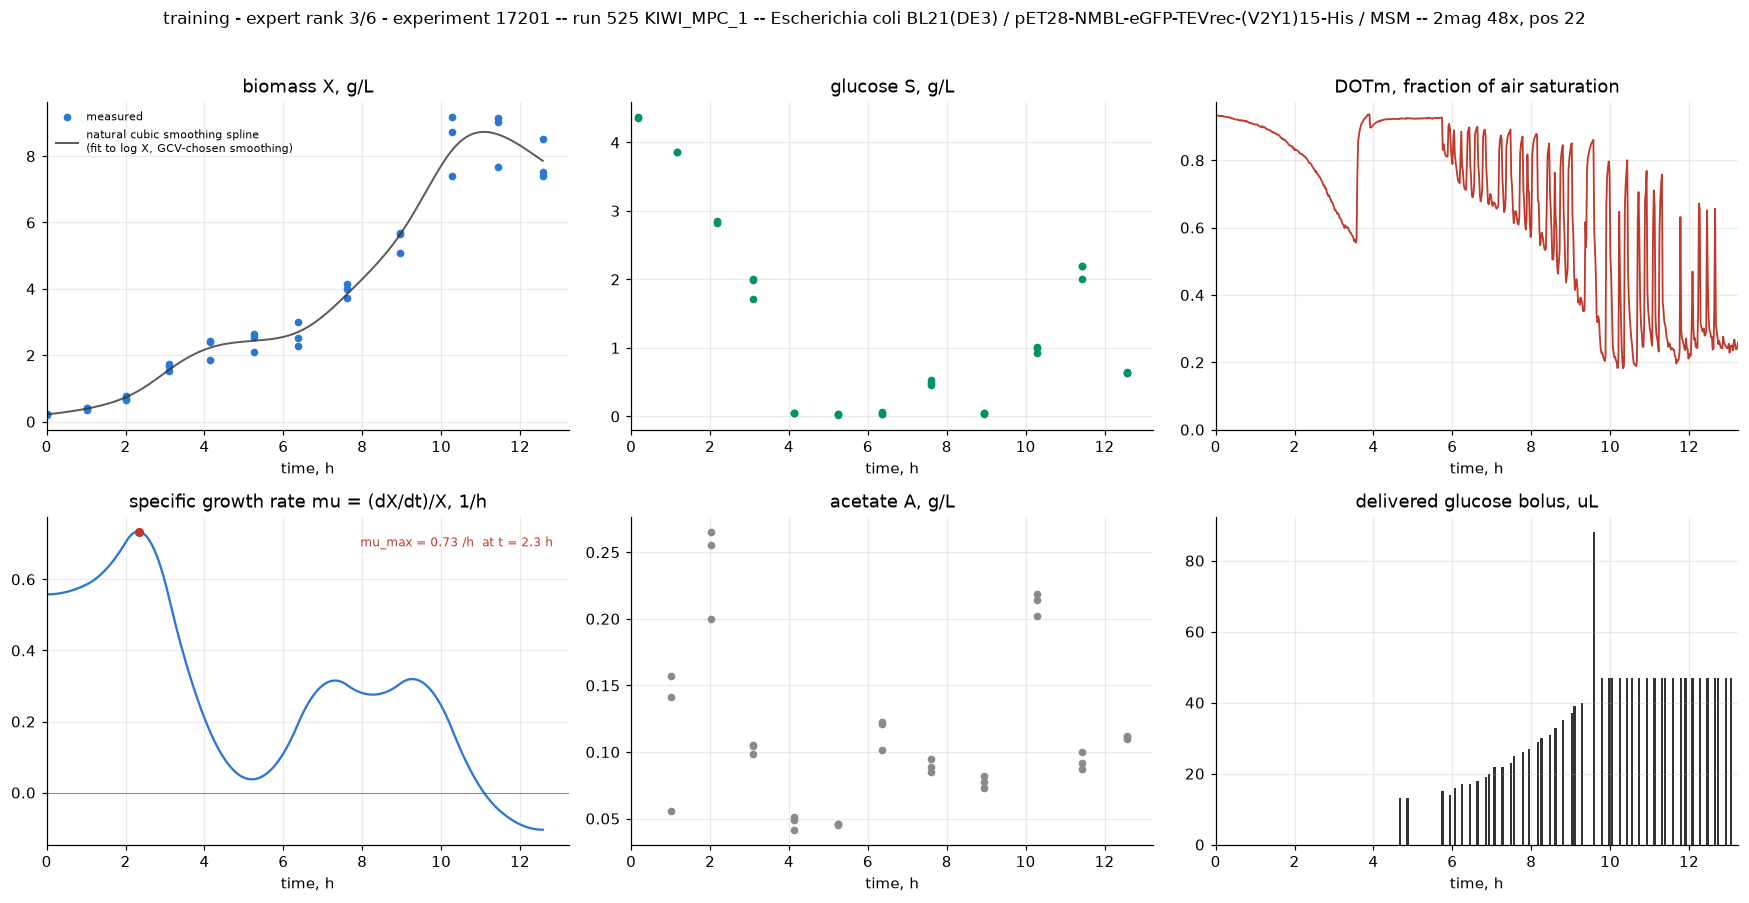

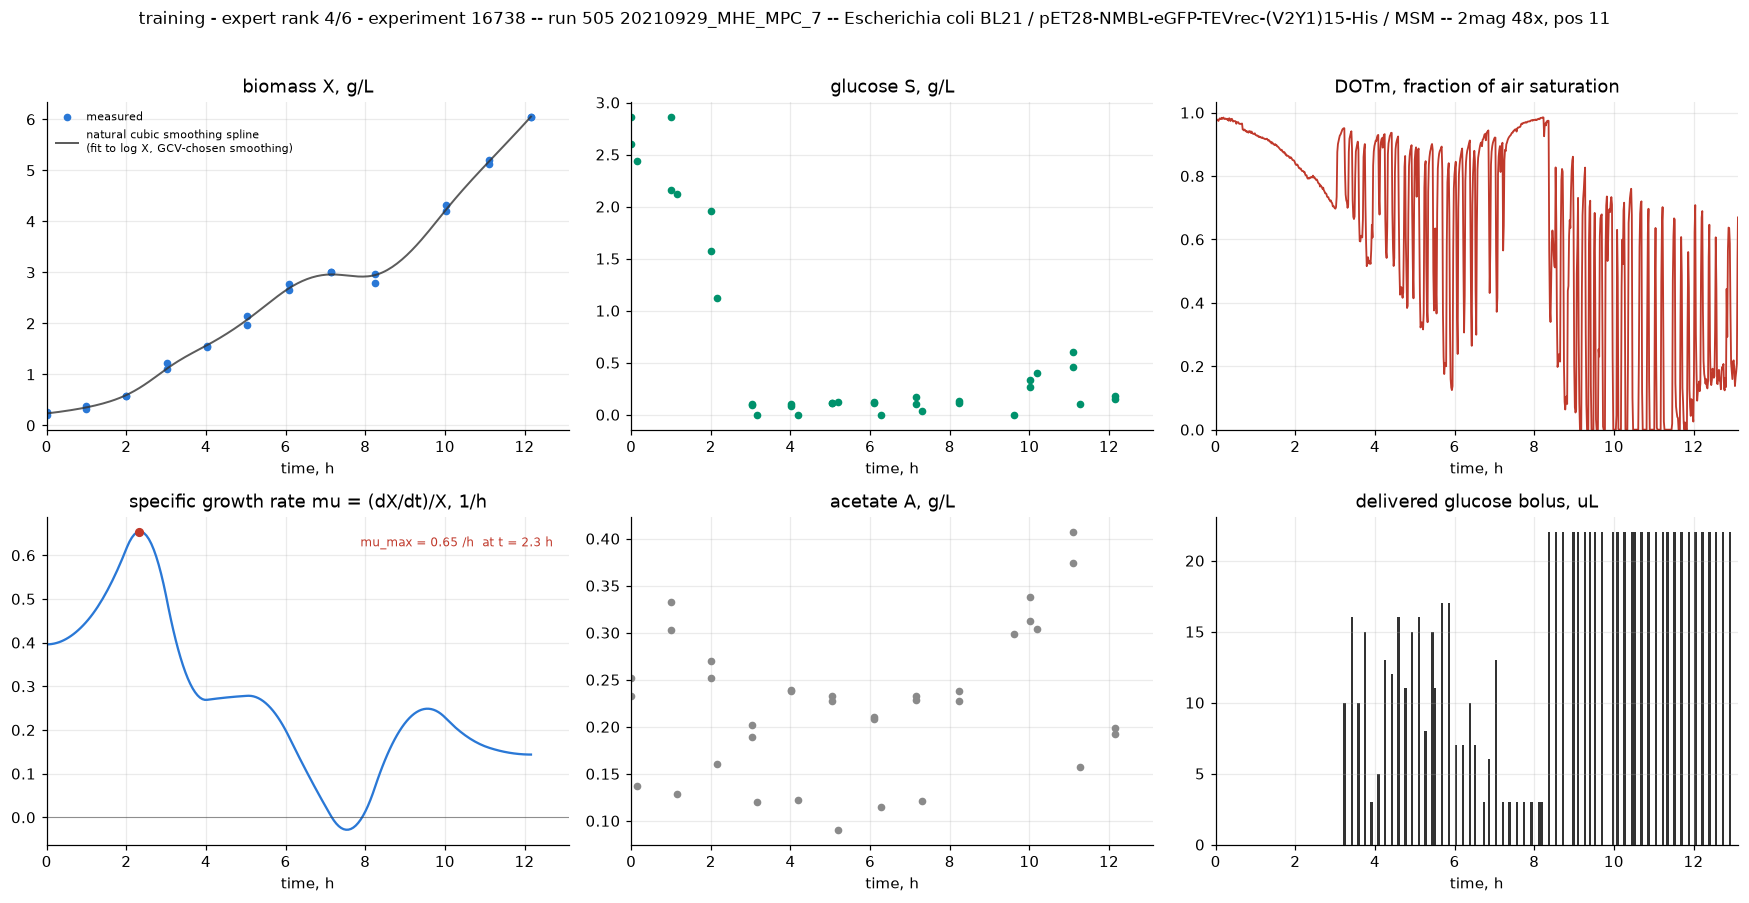

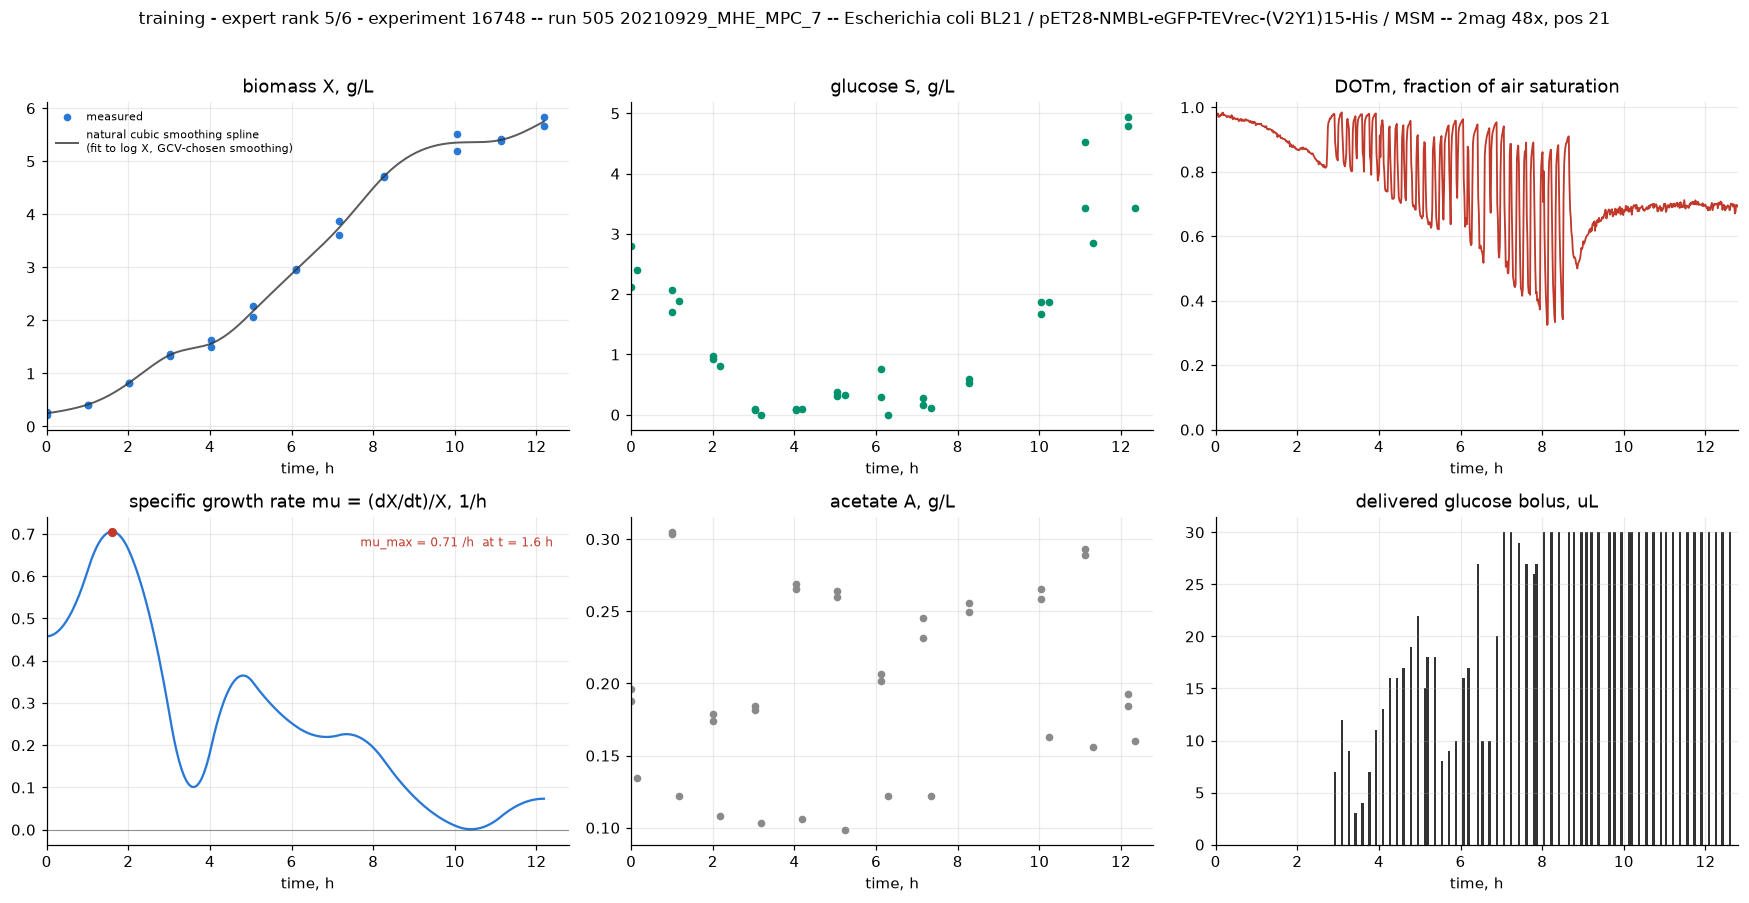

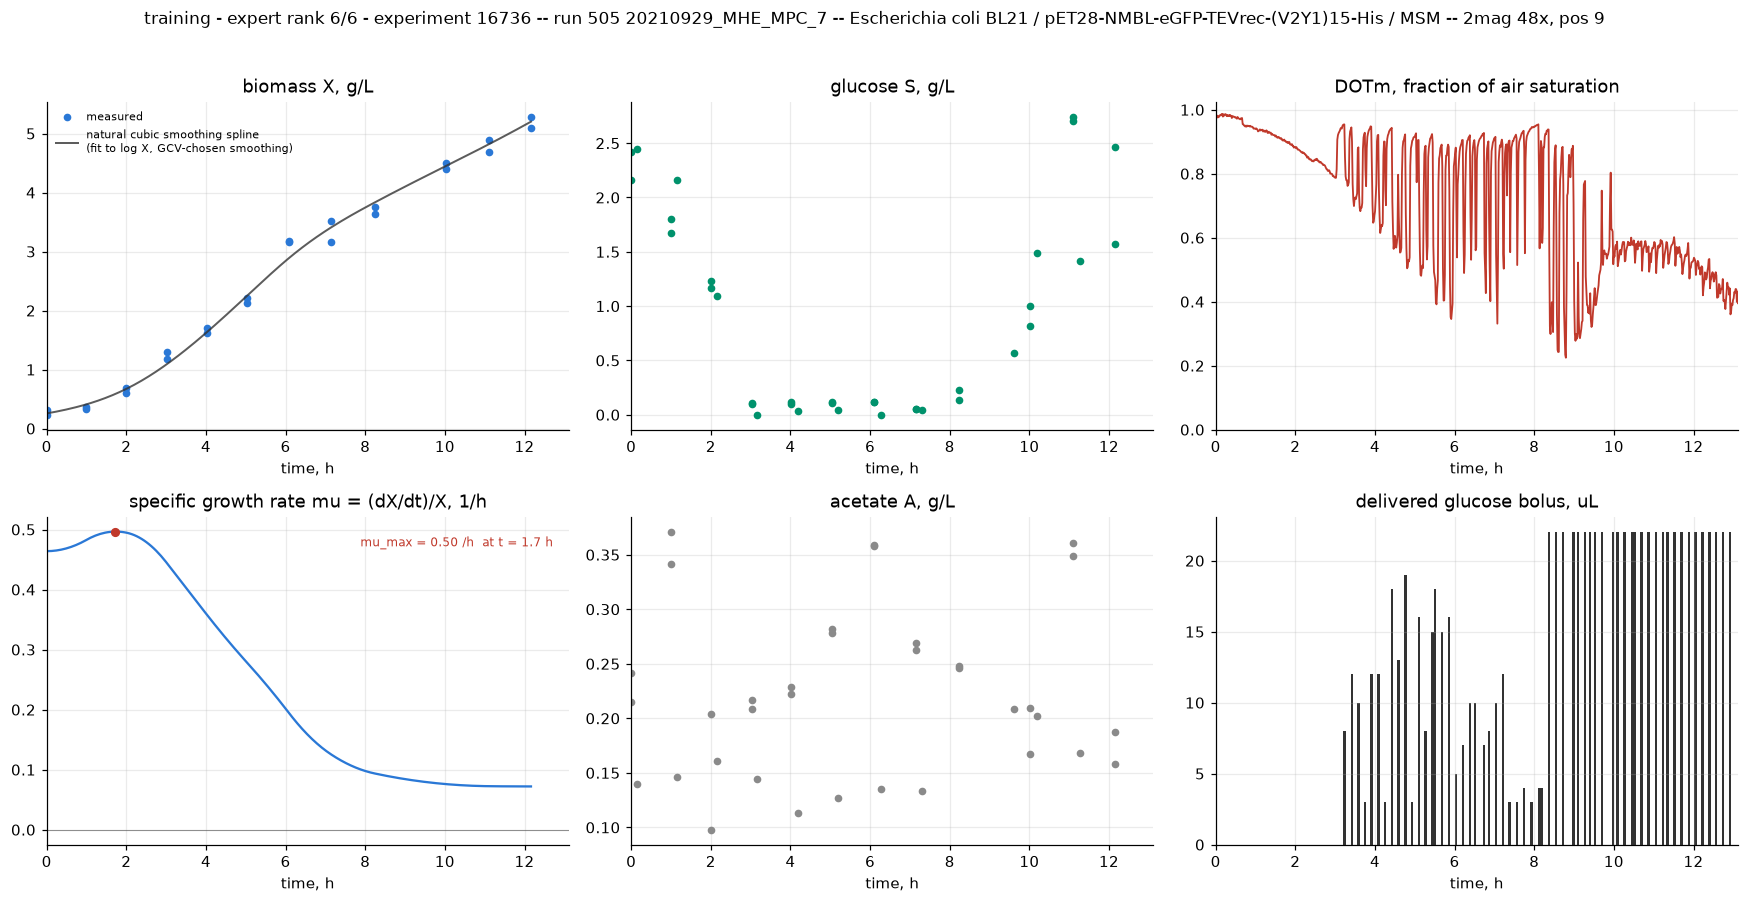

In [4]:
from pathlib import Path
FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)

for rank, experiment_id in enumerate(TRAINING_EXPERT_RANKING):
    experiment = training[experiment_id]
    try:
        reactor = build_reactor(experiment)
    except MissingChannel as error:
        print("experiment %d: skipped -- %s" % (experiment_id, error)); continue
    draw(experiment, reactor,
         "training - expert rank %d/%d - experiment %d -- %s"
         % (rank + 1, len(TRAINING_EXPERT_RANKING), experiment_id, experiment.describe()),
         "train_rank_%d_exp_id_%d.png" % (rank + 1, experiment_id), FIG_DIR)

## Validation reactors — expert order hidden

Shown in numeric id order. There is no rank or class label: the expert ranking of these five is only on the server.

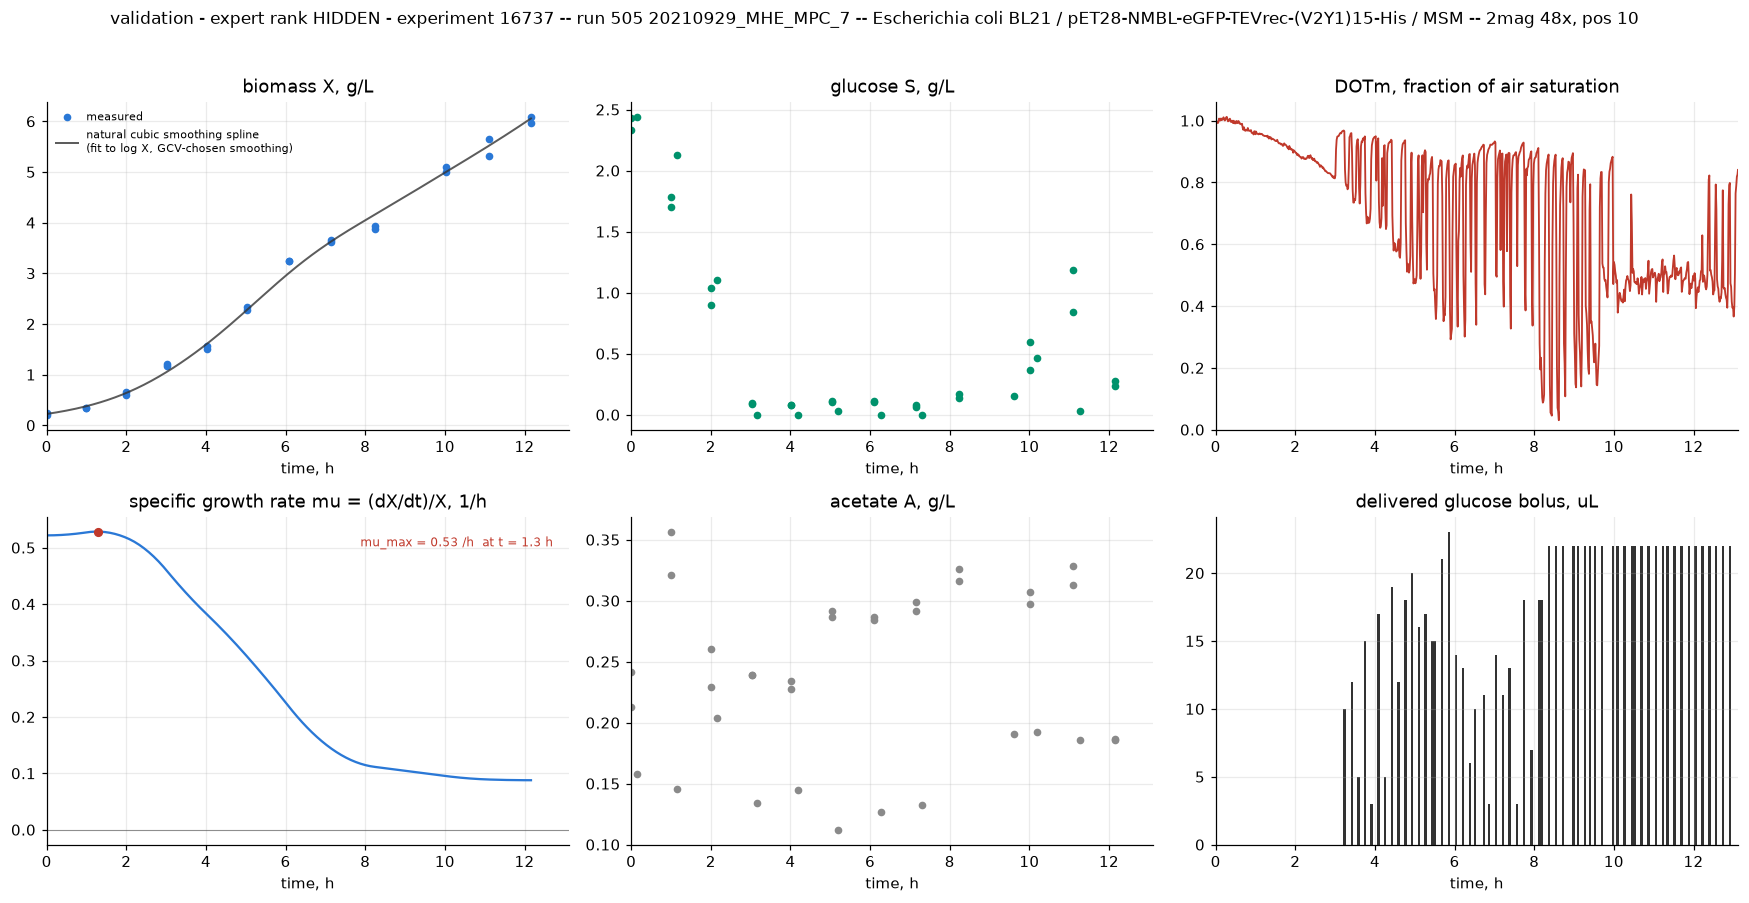

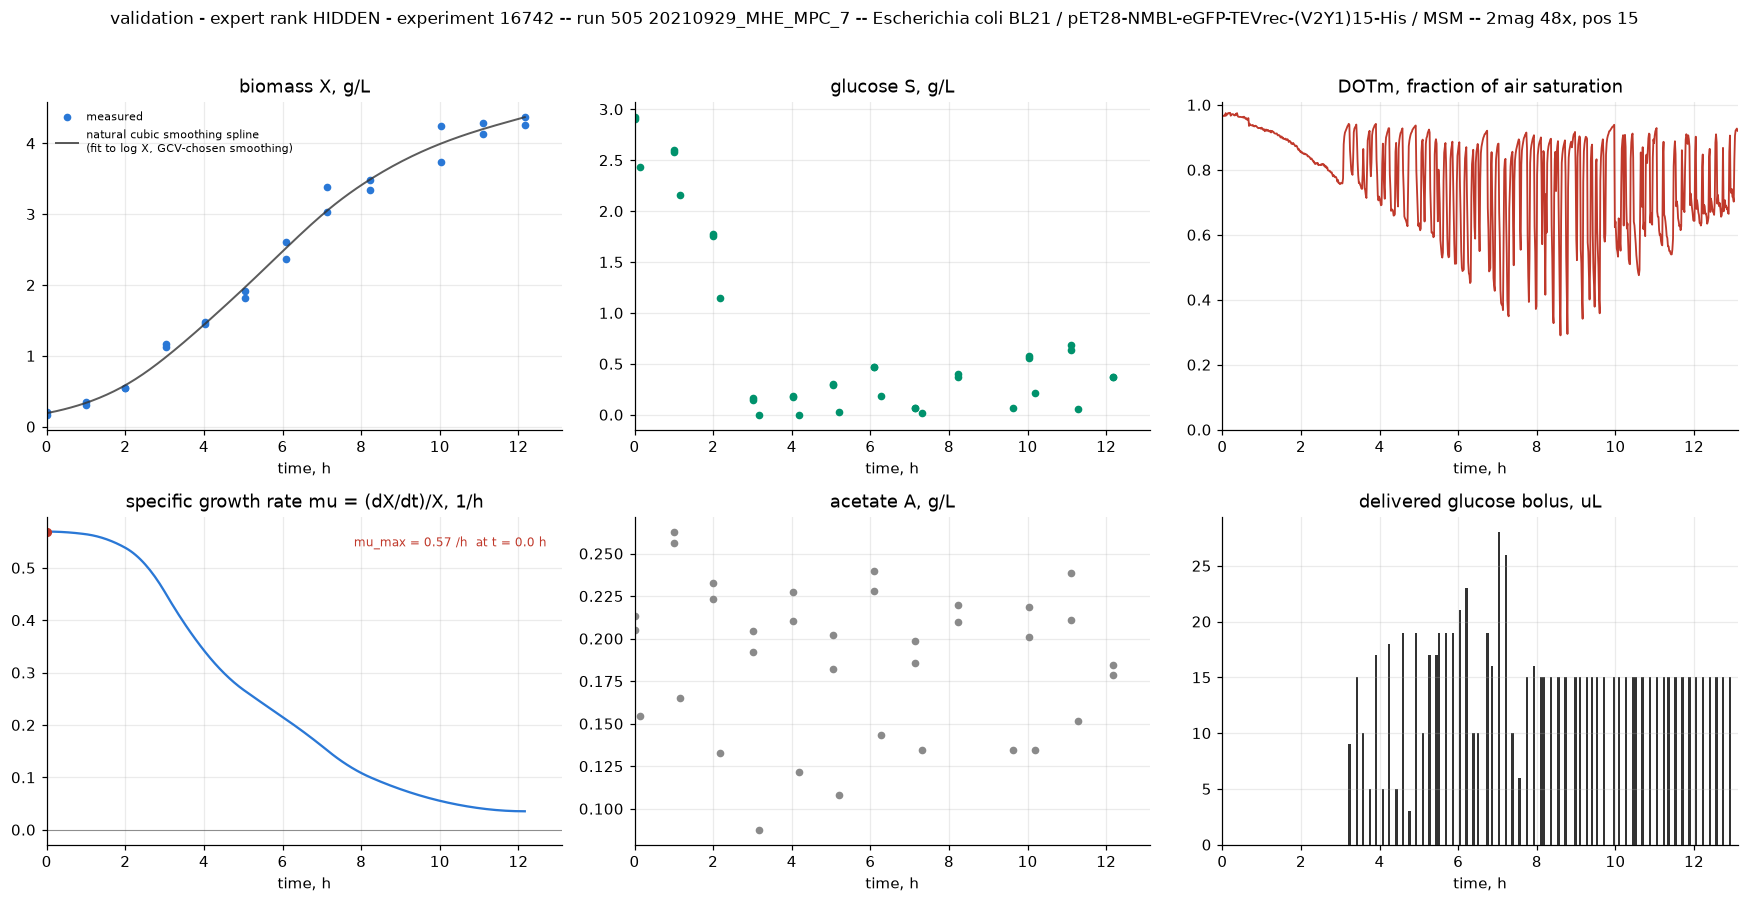

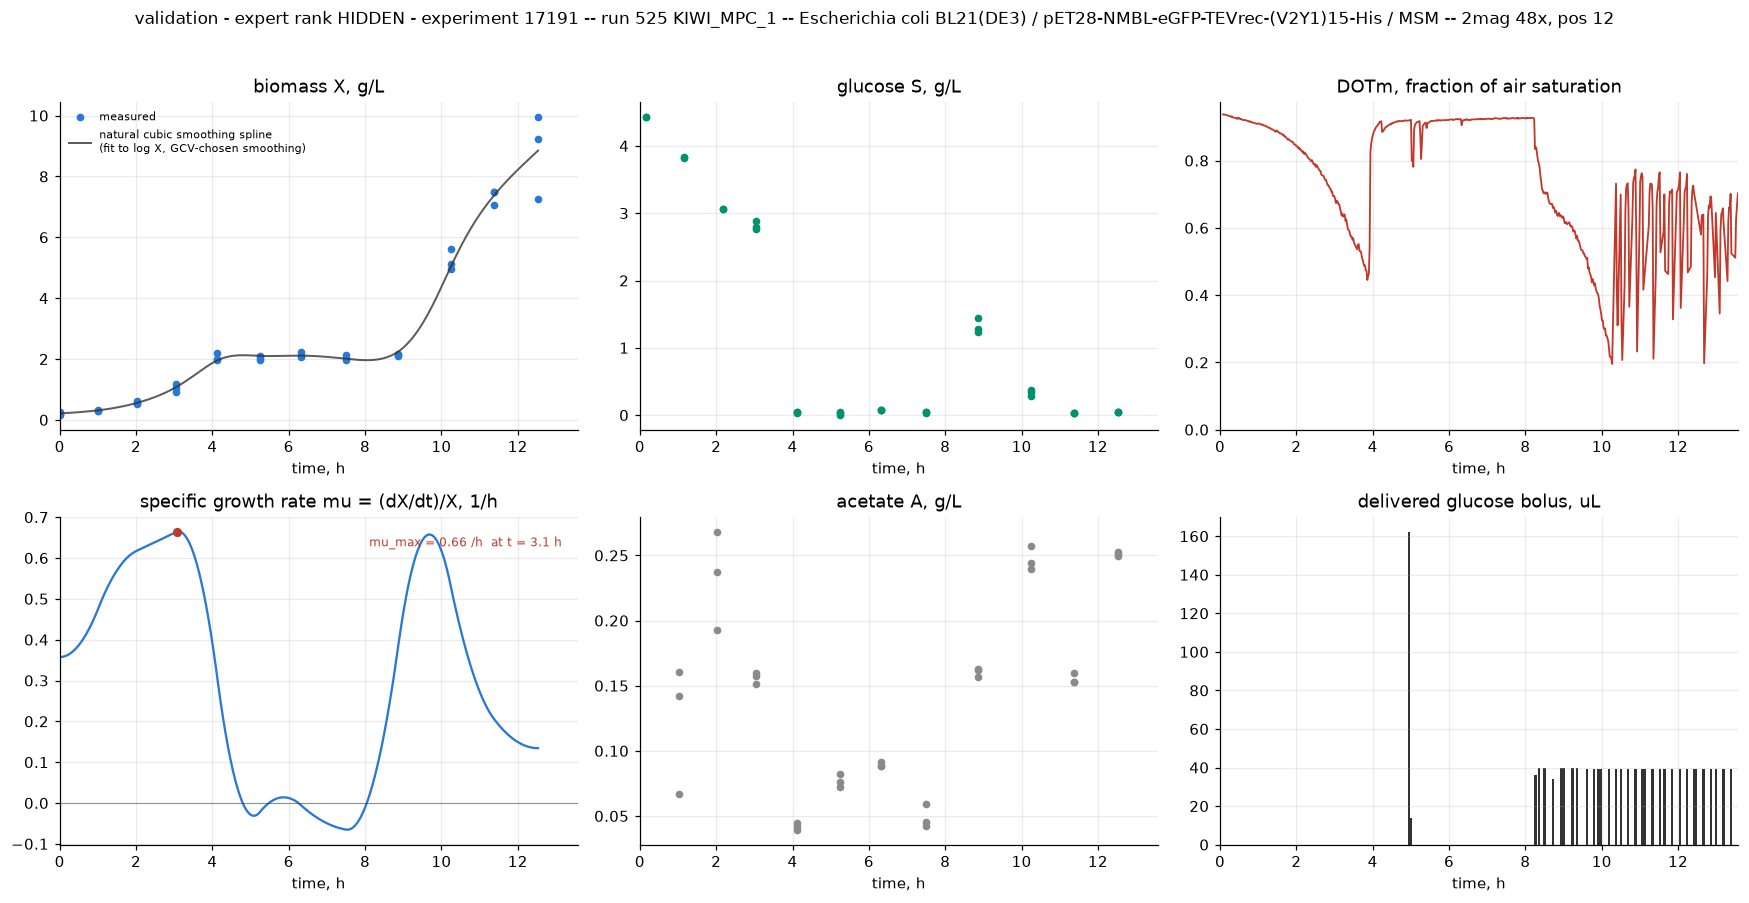

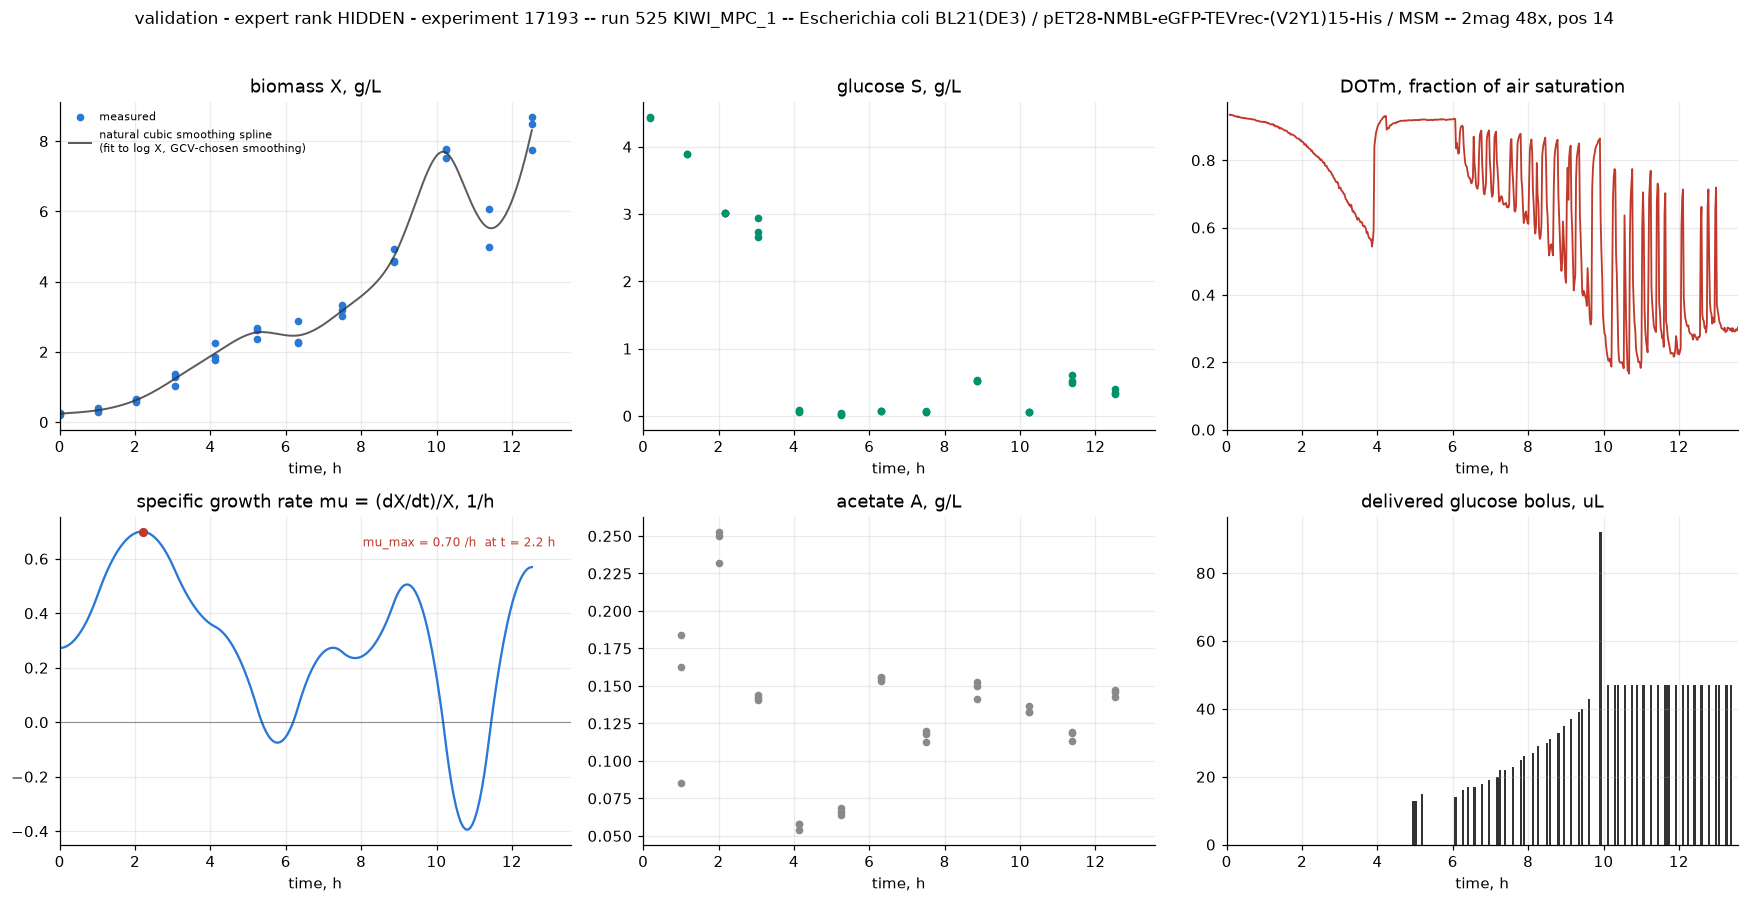

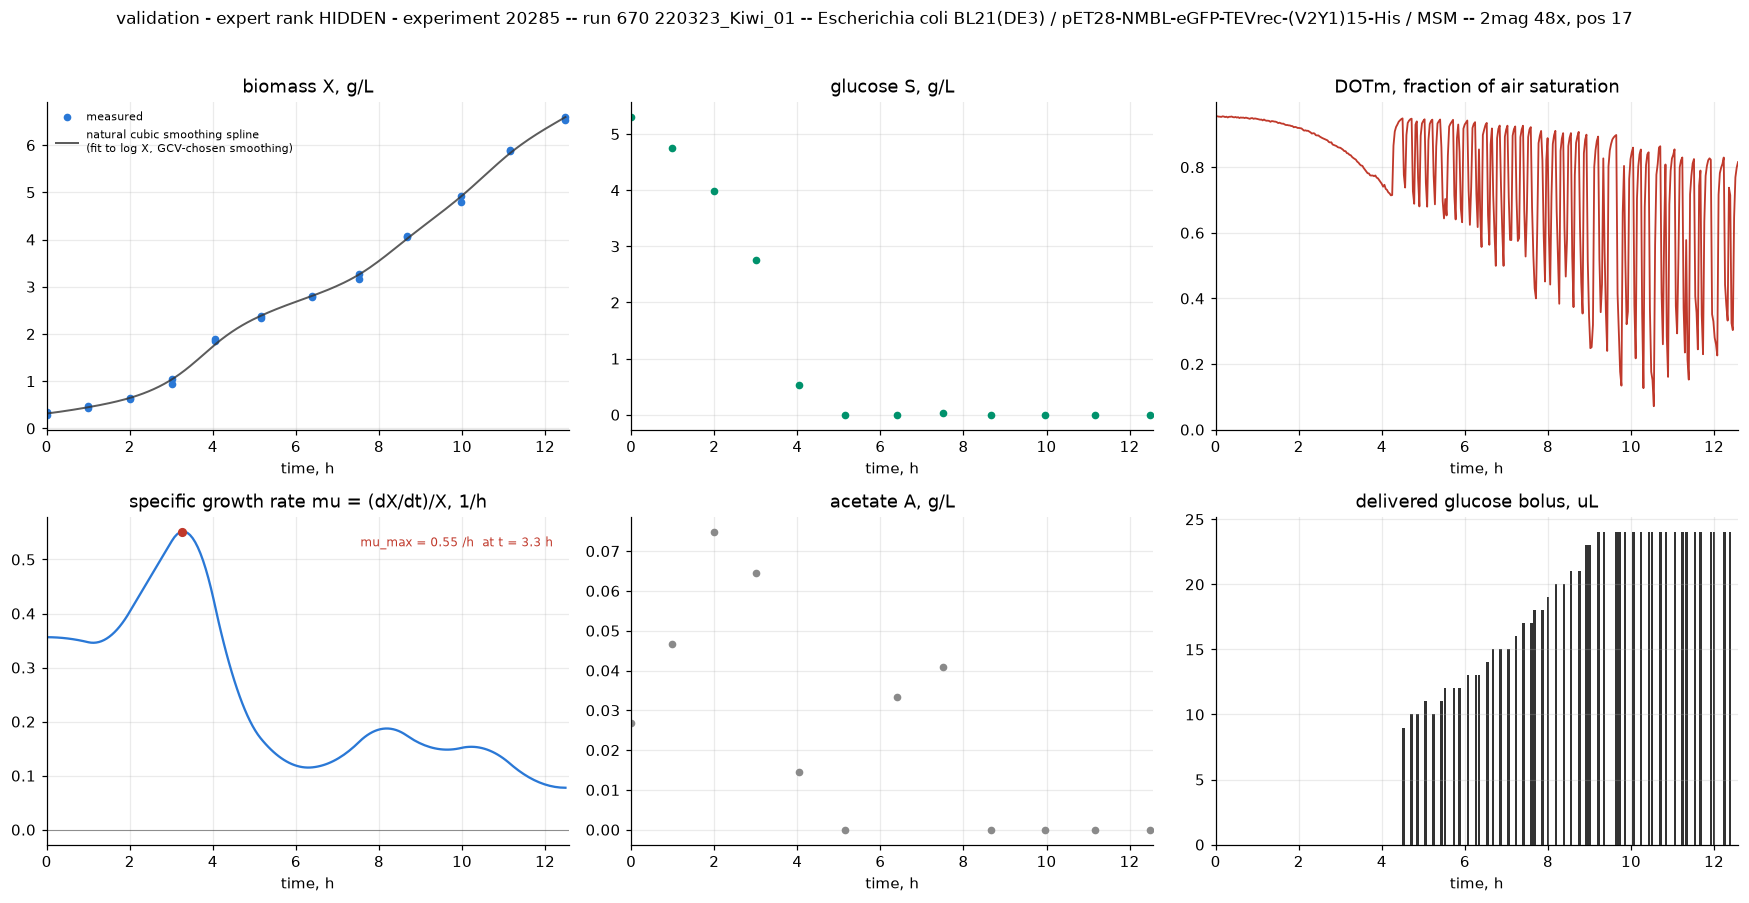

In [5]:
for experiment_id in VALIDATION_IDS:
    experiment = validation[experiment_id]
    try:
        reactor = build_reactor(experiment)
    except MissingChannel as error:
        print("experiment %d: skipped -- %s" % (experiment_id, error)); continue
    draw(experiment, reactor,
         "validation - expert rank HIDDEN - experiment %d -- %s"
         % (experiment_id, experiment.describe()),
         "validation_exp_id_%d.png" % experiment_id, FIG_DIR)

## A first look, by eye

Note what separates the panels of the expert's **top** training reactors from the **bottom**
ones — and carry it into notebook `02`:

- **biomass** — how high does `X` get, and is the climb still steep at the horizon or has it
  flattened / rolled over?
- **growth rate** — is `µ` held high and steady, or does it collapse early?
- **acetate** — does `A` stay near zero, or does it accumulate? Overflow metabolism is the
  classic sign of overfeeding.
- **glucose** — does `S` stay low (carbon-limited, as intended), or does it pile up?
- **DOTm** — does the dissolved oxygen crash to zero (oxygen limitation) or spike (the
  culture stopped consuming)?
- **feed** — is the bolus schedule smooth and increasing, or ragged / interrupted?